In [26]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [27]:
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [28]:
def calculate_bmi(state:BMIState)->BMIState:
    weight=state["weight_kg"]
    height=state["height_m"]
    bmi=weight/(height**2)
    state['bmi']=round(bmi,2)
    return state

In [29]:
def category_bmi(state:BMIState)->BMIState:
    bmi=state['bmi']
    if bmi < 18.5:
        state['category'] = "Underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal weight"
    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese"
    return state

In [31]:
graph=StateGraph(BMIState)

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('category_bmi',category_bmi)

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','category_bmi')
graph.add_edge('category_bmi',END)

In [32]:
workflow=graph.compile()

In [33]:
initial_state={'weight_kg':80,'height_m':1.73}
final_state=workflow.invoke(initial_state)

In [34]:
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


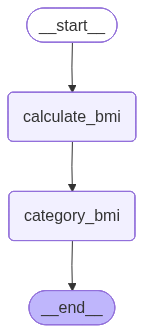

In [35]:

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())